In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [4]:
df= pd.read_csv("/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
import os

In [3]:
os.getcwd()

'/content'

In [5]:
df.shape

(284807, 31)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [8]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [9]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [10]:
df["Class"].value_counts(normalize = True)*100

,proportion
Class,
0,99.827251
1,0.172749


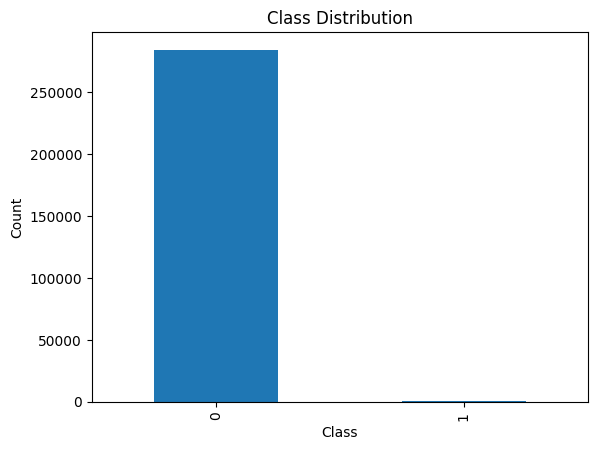

In [11]:
df["Class"].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [12]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [13]:
df["Amount"].describe()

,Amount
count,284807.000000
mean,88.349619
std,250.120109
min,0.000000
25%,5.600000
50%,22.000000
75%,77.165000
max,25691.160000


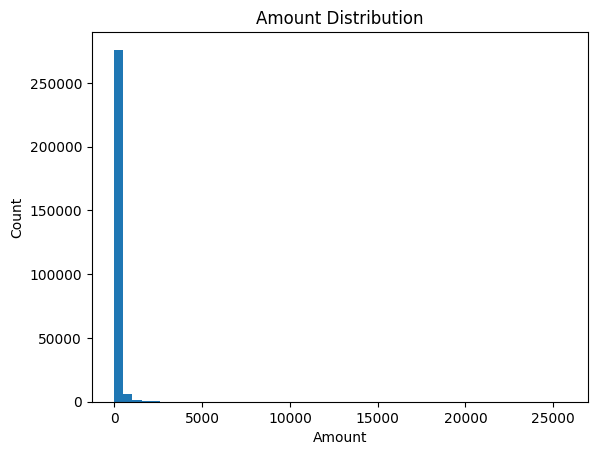

In [14]:
plt.hist(df["Amount"],bins = 50)
plt.title("Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.show()

In [15]:
X = df.drop('Class',axis = 1)
y = df['Class']

In [16]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify = y
)

In [17]:
print("Train distributer :")
print(y_train.value_counts())

print("\nTest distributer :")
print(y_test.value_counts())

Train distributer :
Class
0    227451
1       394
Name: count, dtype: int64

Test distributer :
Class
0    56864
1       98
Name: count, dtype: int64


In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()

In [20]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [21]:
print(np.mean(X_train_scaled))
print(np.std(X_train_scaled))

-8.159128549351572e-18
1.0000000000000004


In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
log_reg = LogisticRegression(
    max_iter = 10000,
    random_state = 42
)
log_reg.fit(X_train_scaled,y_train)

LogisticRegression(max_iter=10000, random_state=42)

In [24]:
y_pred = log_reg.predict(X_test_scaled)

In [25]:
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:,1]

In [27]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)
cm = confusion_matrix(y_test,y_pred)
cm

array([[56851,    13],
       [   36,    62]])

In [28]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [29]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_pred_proba)
roc_auc


np.float64(0.9605494455801453)

In [32]:
log_reg_w = LogisticRegression(
    max_iter = 10000,
    random_state = 42,
    class_weight = "balanced"
)
log_reg_w.fit(X_train_scaled,y_train
)

LogisticRegression(class_weight='balanced', max_iter=10000, random_state=42)

In [33]:
y_pred_w = log_reg_w.predict(X_test_scaled)
y_pred_proba_w = log_reg_w.predict_proba(X_test_scaled)[:,1]

In [34]:
print(confusion_matrix(y_test,y_pred_w))

[[55478  1386]
 [    8    90]]


In [35]:
print(classification_report(y_test,y_pred_w))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [36]:
import numpy as np
threshold = 0.3
y_pred_custom = (y_pred_proba_w >= threshold).astype(int)

In [37]:
print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))


[[53663  3201]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     56864
           1       0.03      0.92      0.05        98

    accuracy                           0.94     56962
   macro avg       0.51      0.93      0.51     56962
weighted avg       1.00      0.94      0.97     56962



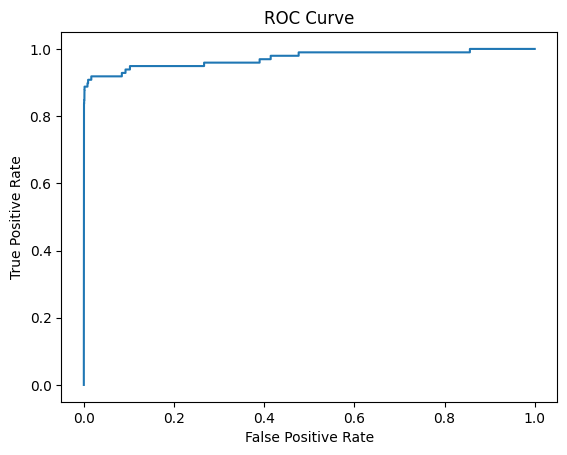

In [38]:
fpr ,tpr, _ = roc_curve(y_test,y_pred_proba_w)
plt.plot(fpr , tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [39]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
rf = RandomForestClassifier(
    n_estimators = 100,
    random_state = 42,
    class_weight = "balanced",
    n_jobs = -1
)
rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [42]:
y_pred_rf = rf.predict(X_test)
y_pred_proba_rf = rf.predict_proba(X_test)[:,1]

In [43]:
print(confusion_matrix(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))
print(roc_auc_score(y_test,y_pred_proba_rf))

[[56861     3]
 [   25    73]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.74      0.84        98

    accuracy                           1.00     56962
   macro avg       0.98      0.87      0.92     56962
weighted avg       1.00      1.00      1.00     56962

0.952908497036969


In [44]:
from sklearn.ensemble import GradientBoostingClassifier

In [45]:
gb = GradientBoostingClassifier(
    n_estimators = 150,
    random_state = 42,
    learning_rate = 0.1
)
gb.fit(X_train,y_train)

GradientBoostingClassifier(n_estimators=150, random_state=42)

In [46]:
y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_gb))


[[56848    16]
 [   80    18]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.53      0.18      0.27        98

    accuracy                           1.00     56962
   macro avg       0.76      0.59      0.64     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.3468859283302516


In [47]:
! pip install xgboost

In [48]:
from xgboost import XGBClassifier

In [49]:
xgb = XGBClassifier(
    n_estimators = 300,
    random_state = 42,
    learning_rate = 0.05,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = 10,
    n_jobs = -1
)
xgb.fit(X_train,y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=-1, num_parallel_tree=None, ...)

In [50]:
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:,1]

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))


[[56854    10]
 [   16    82]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9778614280546208


In [51]:
! pip install lightgbm

In [52]:
from lightgbm import LGBMClassifier

In [59]:
lgbm = LGBMClassifier(
    n_estimators = 400,
    random_state = 42,
    class_weight='balanced',
    learning_rate = 0.05,
)

lgbm.fit(X_train,y_train)

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.057665 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=400,
               random_state=42)

In [60]:
y_pred_lgb = lgbm.predict(X_test)
y_proba_lgb = lgbm.predict_proba(X_test)[:,1]

print(confusion_matrix(y_test, y_pred_lgb))
print(classification_report(y_test, y_pred_lgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lgb))

[[56855     9]
 [   17    81]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.90      0.83      0.86        98

    accuracy                           1.00     56962
   macro avg       0.95      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9427188608983267


In [62]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(name ,y_true,y_pred,y_proba):
  return{
      "Model": name,
      "ROC-AUC": roc_auc_score(y_true,y_proba),
      "Precision": precision_score(y_true,y_pred),
      "Recall": recall_score(y_true,y_pred),
      "F1-Score": f1_score(y_true,y_pred)
  }


In [63]:
results = []

results.append(evaluate_model(
    "Logistic (weighted)",
    y_test,
    y_pred_w,
    y_pred_proba_w
))

results.append(evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf,
    y_pred_proba_rf
))

results.append(evaluate_model(
    "Gradient Boost",
    y_test,
    y_pred_gb,
    y_proba_gb
))

results.append(evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb,
    y_proba_xgb
))

results.append(evaluate_model(
    "LightGBM",
    y_test,
    y_pred_lgb,
    y_proba_lgb
))

In [64]:
results_df = pd.DataFrame(results)
results_df=results_df.sort_values(by="ROC-AUC",ascending=False)
results_df

,Model,ROC-AUC,Precision,Recall,F1-Score
3,XGBoost,0.977861,0.891304,0.836735,0.863158
0,Logistic (weighted),0.972083,0.060976,0.918367,0.114358
1,Random Forest,0.952908,0.960526,0.744898,0.839080
4,LightGBM,0.942719,0.900000,0.826531,0.861702
2,Gradient Boost,0.346886,0.529412,0.183673,0.272727


In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [66]:
param_grid = {
    'C': [0.01,0.1,1,5,10],
    "penalty": ["l1","l2"],
    "solver": ["liblinear"],
    "class_weight": ["balanced"],
    "max_iter": [1000]



}

In [68]:
log_base = LogisticRegression()

In [69]:
grid = GridSearchCV(
    log_base,
    param_grid,
    scoring = "roc_auc",
    cv = 5,
    n_jobs = -1,
    verbose = 1
)

In [70]:
grid.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 5, 10],
                         'class_weight': ['balanced'], 'max_iter': [1000],
                         'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
             scoring='roc_auc', verbose=1)

In [75]:
grid.best_params_
best_log = grid.best_estimator_

In [76]:
y_pred_best = best_log.predict(X_test_scaled)
y_proba_best = best_log.predict_proba(X_test_scaled)[:,1]

print(confusion_matrix(y_test,y_pred_best))
print(classification_report(y_test,y_pred_best))
print("ROC - AUc :",roc_auc_score(y_test,y_proba_best))

[[55496  1368]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC - AUc : 0.9726819558014539


In [77]:
best_log

LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                   solver='liblinear')

In [79]:
import pandas as pd

coef = best_log.coef_[0]
feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coef
})



In [81]:
importance_df["AbsCoef"]=importance_df["Importance"].abs()
importtance_df = importance_df.sort_values(by="AbsCoef",ascending=False)

importance_df.head()

,Feature,Importance,AbsCoef
0,Time,-0.366545,0.366545
1,V1,0.766915,0.766915
2,V2,0.098385,0.098385
3,V3,0.015020,0.015020
4,V4,1.287529,1.287529


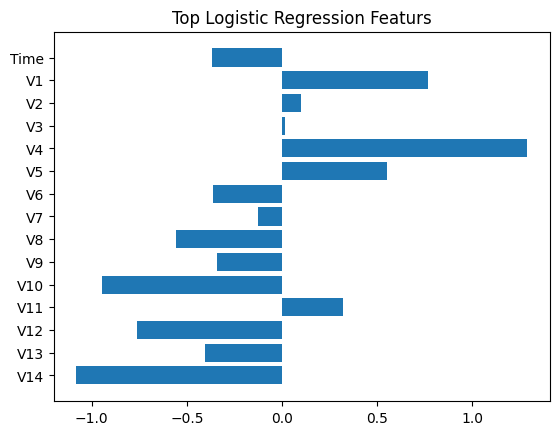

In [84]:
import matplotlib.pyplot as plt

top = importance_df.head(15)

plt.barh(top['Feature'], top['Cofficient'])
plt.title("Top Logistic Regression Featurs")
plt.gca().invert_yaxis()
plt.show()

In [87]:
sample=X_test_scaled[0].reshape(1,-1)
best_log.predict(sample)

array([0])

In [88]:
y_proba_best

array([0.0143528 , 0.06509849, 0.00309584, ..., 0.00054004, 0.00539727,
       0.09958975])

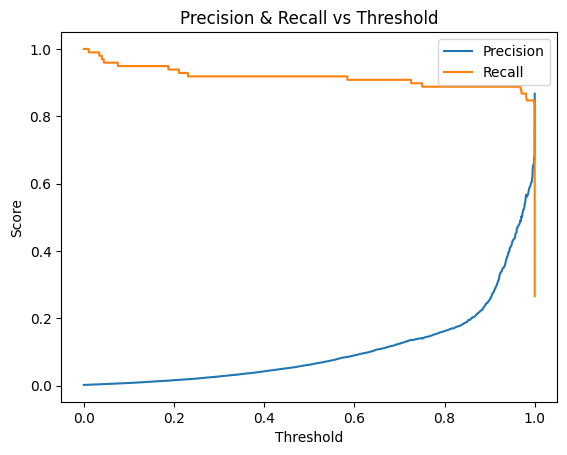

In [93]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)

plt.plot(thresholds,Precision[:-1],label = "Precision")
plt.plot(thresholds,recalls[:-1],label = "Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold")
plt.legend()
plt.show()

In [97]:
best_threshold = 0.3
y_pred_tuned = (y_proba_best >= best_threshold).astype(int)

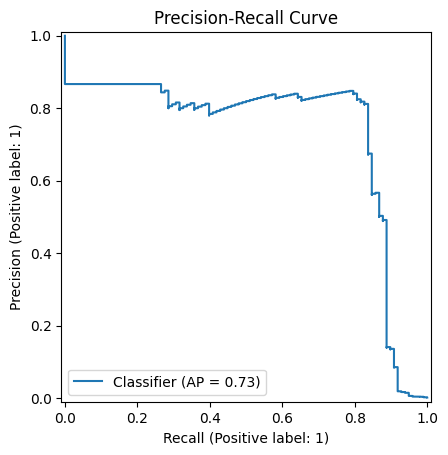

In [98]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba_best,
)
plt.title("Precision-Recall Curve")
plt.show()

In [99]:
import joblib

joblib.dump(best_log,"Froud_model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [100]:
model_loaded = joblib.load("Froud_model.pkl")
scaler_loaded = joblib.load("scaler.pkl")